In [2]:
from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
from typing import TypedDict

In [3]:
class bmiState(TypedDict):
    weight: float
    height: float
    bmi: float
    category: str

In [5]:
def compute_bmi(state: bmiState) -> bmiState:
    weight = state['weight']
    height = state['height']
    bmi = weight / (height ** 2)
    state['bmi'] = round(bmi,2)

    return state

In [6]:
def label_bmi(state: bmiState) -> bmiState:
    bmi = state['bmi']
    if bmi < 18.5:
        state['category'] = 'Underweight'
    elif 18.5 <= bmi < 25:
        state['category'] = 'Normal weight'
    elif 25 <= bmi < 30:
        state['category'] = 'Overweight'
    else:
        state['category'] = 'Obese'

    return state

In [13]:
graph = StateGraph(bmiState)

# Add the nodes
graph.add_node('BMI Computation', compute_bmi)
graph.add_node('BMI Labeling', label_bmi)
# Add the edges
graph.add_edge(START, 'BMI Computation')
graph.add_edge('BMI Computation', 'BMI Labeling')
graph.add_edge('BMI Labeling', END)
# Compile the graph
workflow = graph.compile()

In [14]:
# execute the graph
intial_state = {'weight':80, 'height':1.73}

final_state = workflow.invoke(intial_state)

print(final_state)

{'weight': 80, 'height': 1.73, 'bmi': 26.73, 'category': 'Overweight'}


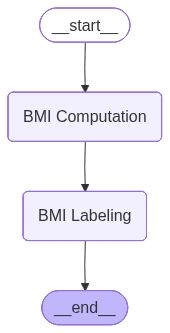

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())